# Principal Component Analysis with Cancer Data

In [111]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [112]:
cancer = pd.read_csv("breast-cancer-wisconsin-data.csv")
cancer.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [113]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

In [114]:
# drop duplicates
print('Duplicate records {0}'.format(cancer.duplicated().sum()))
cancer.drop_duplicates(keep='first',inplace=True)

Duplicate records 8


In [115]:
cancer = cancer.drop(['ID'],axis=1)

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [116]:
cancer['Class'].value_counts()

2    453
4    238
Name: Class, dtype: int64

In [117]:
cancer.info()
cancer.dtypes
cancer.isnull().any()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 691 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 691 non-null int64
Cell Size                      691 non-null int64
Cell Shape                     691 non-null int64
Marginal Adhesion              691 non-null int64
Single Epithelial Cell Size    691 non-null int64
Bare Nuclei                    691 non-null object
Normal Nucleoli                691 non-null int64
Bland Chromatin                691 non-null int64
Mitoses                        691 non-null int64
Class                          691 non-null int64
dtypes: int64(9), object(1)
memory usage: 59.4+ KB


ClumpThickness                 False
Cell Size                      False
Cell Shape                     False
Marginal Adhesion              False
Single Epithelial Cell Size    False
Bare Nuclei                    False
Normal Nucleoli                False
Bland Chromatin                False
Mitoses                        False
Class                          False
dtype: bool

In [118]:
cancer.replace(to_replace ="?", value =0, inplace = True) 
cancer ["Bare Nuclei"] = cancer ["Bare Nuclei"].astype ('int64',copy=True) 
#cancer=cancer.replace(0,mean_Bare Nuclei) 
#cancer=cancer.replace({'Bare Nuclei': {0: mean_Bare Nuclei}})
cancer.dtypes
cancer.shape

(691, 10)

In [119]:
cancer.head(50)

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2
5,8,10,10,8,7,10,9,7,1,4
6,1,1,1,1,2,10,3,1,1,2
7,2,1,2,1,2,1,3,1,1,2
8,2,1,1,1,2,1,1,1,5,2
9,4,2,1,1,2,1,2,1,1,2


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [120]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [121]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?


In [122]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [123]:
#mean = (cancer['Bare Nuclei'].mean())
cancer ['Bare Nuclei'] = cancer ['Bare Nuclei'].replace(0,(cancer['Bare Nuclei'].mean()))  

In [124]:
cancer.tail(50)

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
648,5,10,10,10,10,2.0,10,10,10,4
649,3,1,1,1,2,1.0,2,1,1,2
650,3,1,1,2,3,4.0,1,1,1,2
651,1,2,1,3,2,1.0,2,1,1,2
652,5,1,1,1,2,1.0,2,2,1,2
653,4,1,1,1,2,1.0,2,1,1,2
654,3,1,1,1,2,1.0,3,1,1,2
655,3,1,1,1,2,1.0,2,1,1,2
656,5,1,1,1,2,1.0,2,1,1,2
657,5,4,5,1,8,1.0,3,6,1,2


In [125]:
cancer['Class'].value_counts()

2    453
4    238
Name: Class, dtype: int64

In [126]:
cancer.groupby(['Class']).mean()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses
Class,,,,,,,,,
2,2.964680,1.328918,1.448124,1.368653,2.125828,1.415854,2.097130,1.293598,1.064018
4,7.210084,6.558824,6.537815,5.596639,5.277311,7.571058,5.983193,5.907563,2.600840


# Q4. Perform bi variate analysis including correlation & pairplots. 


In [127]:
# Check for correlation of variable

In [128]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

Text(0.5, 1.0, 'Correlations')

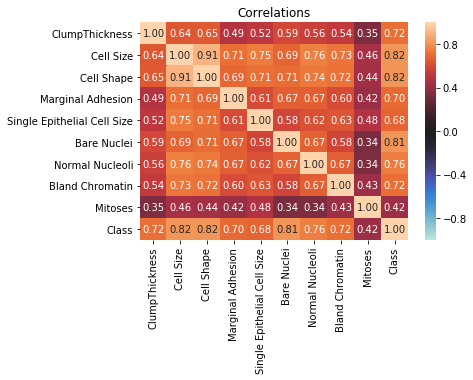

In [129]:
corr_matrix = cancer.corr()
sns.heatmap(corr_matrix,vmin=-1,vmax=1,center=0,annot=True,fmt='.2f')
plt.title('Correlations')

In [130]:
# Correlation exists especially between Cell size and Cell shape. The noise has to be removed/treated in order to maximise benefits from signals

C:\Users\sugan\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


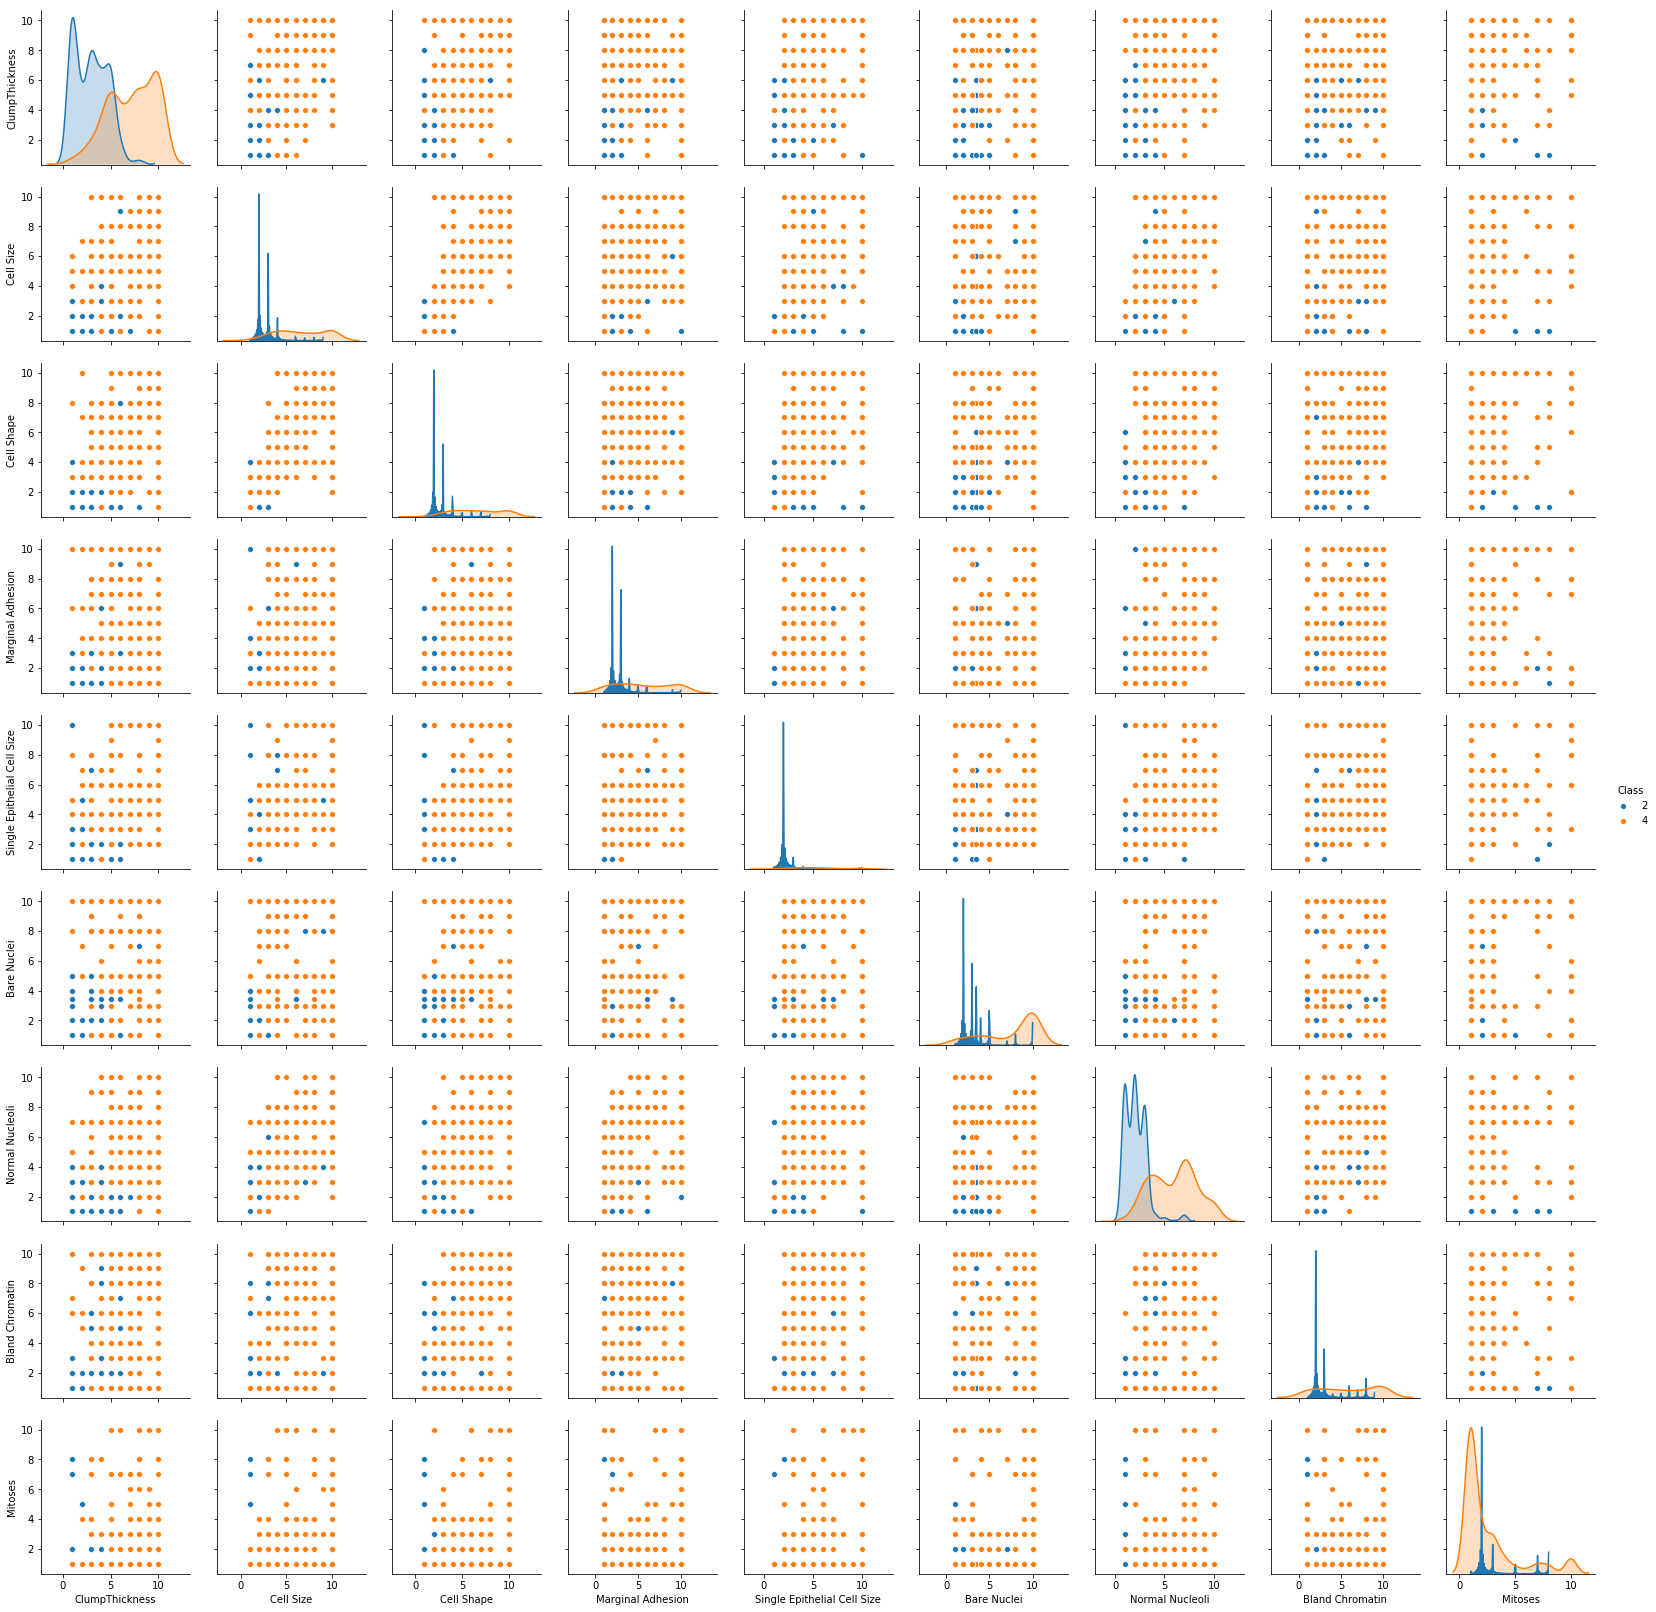

In [131]:
#Check distributions of data
sns.pairplot(data=cancer,hue='Class',vars=['ClumpThickness','Cell Size','Cell Shape','Marginal Adhesion','Single Epithelial Cell Size','Bare Nuclei',
                                           'Normal Nucleoli','Bland Chromatin','Mitoses'])

In [132]:
#Normal distribution is not clear.

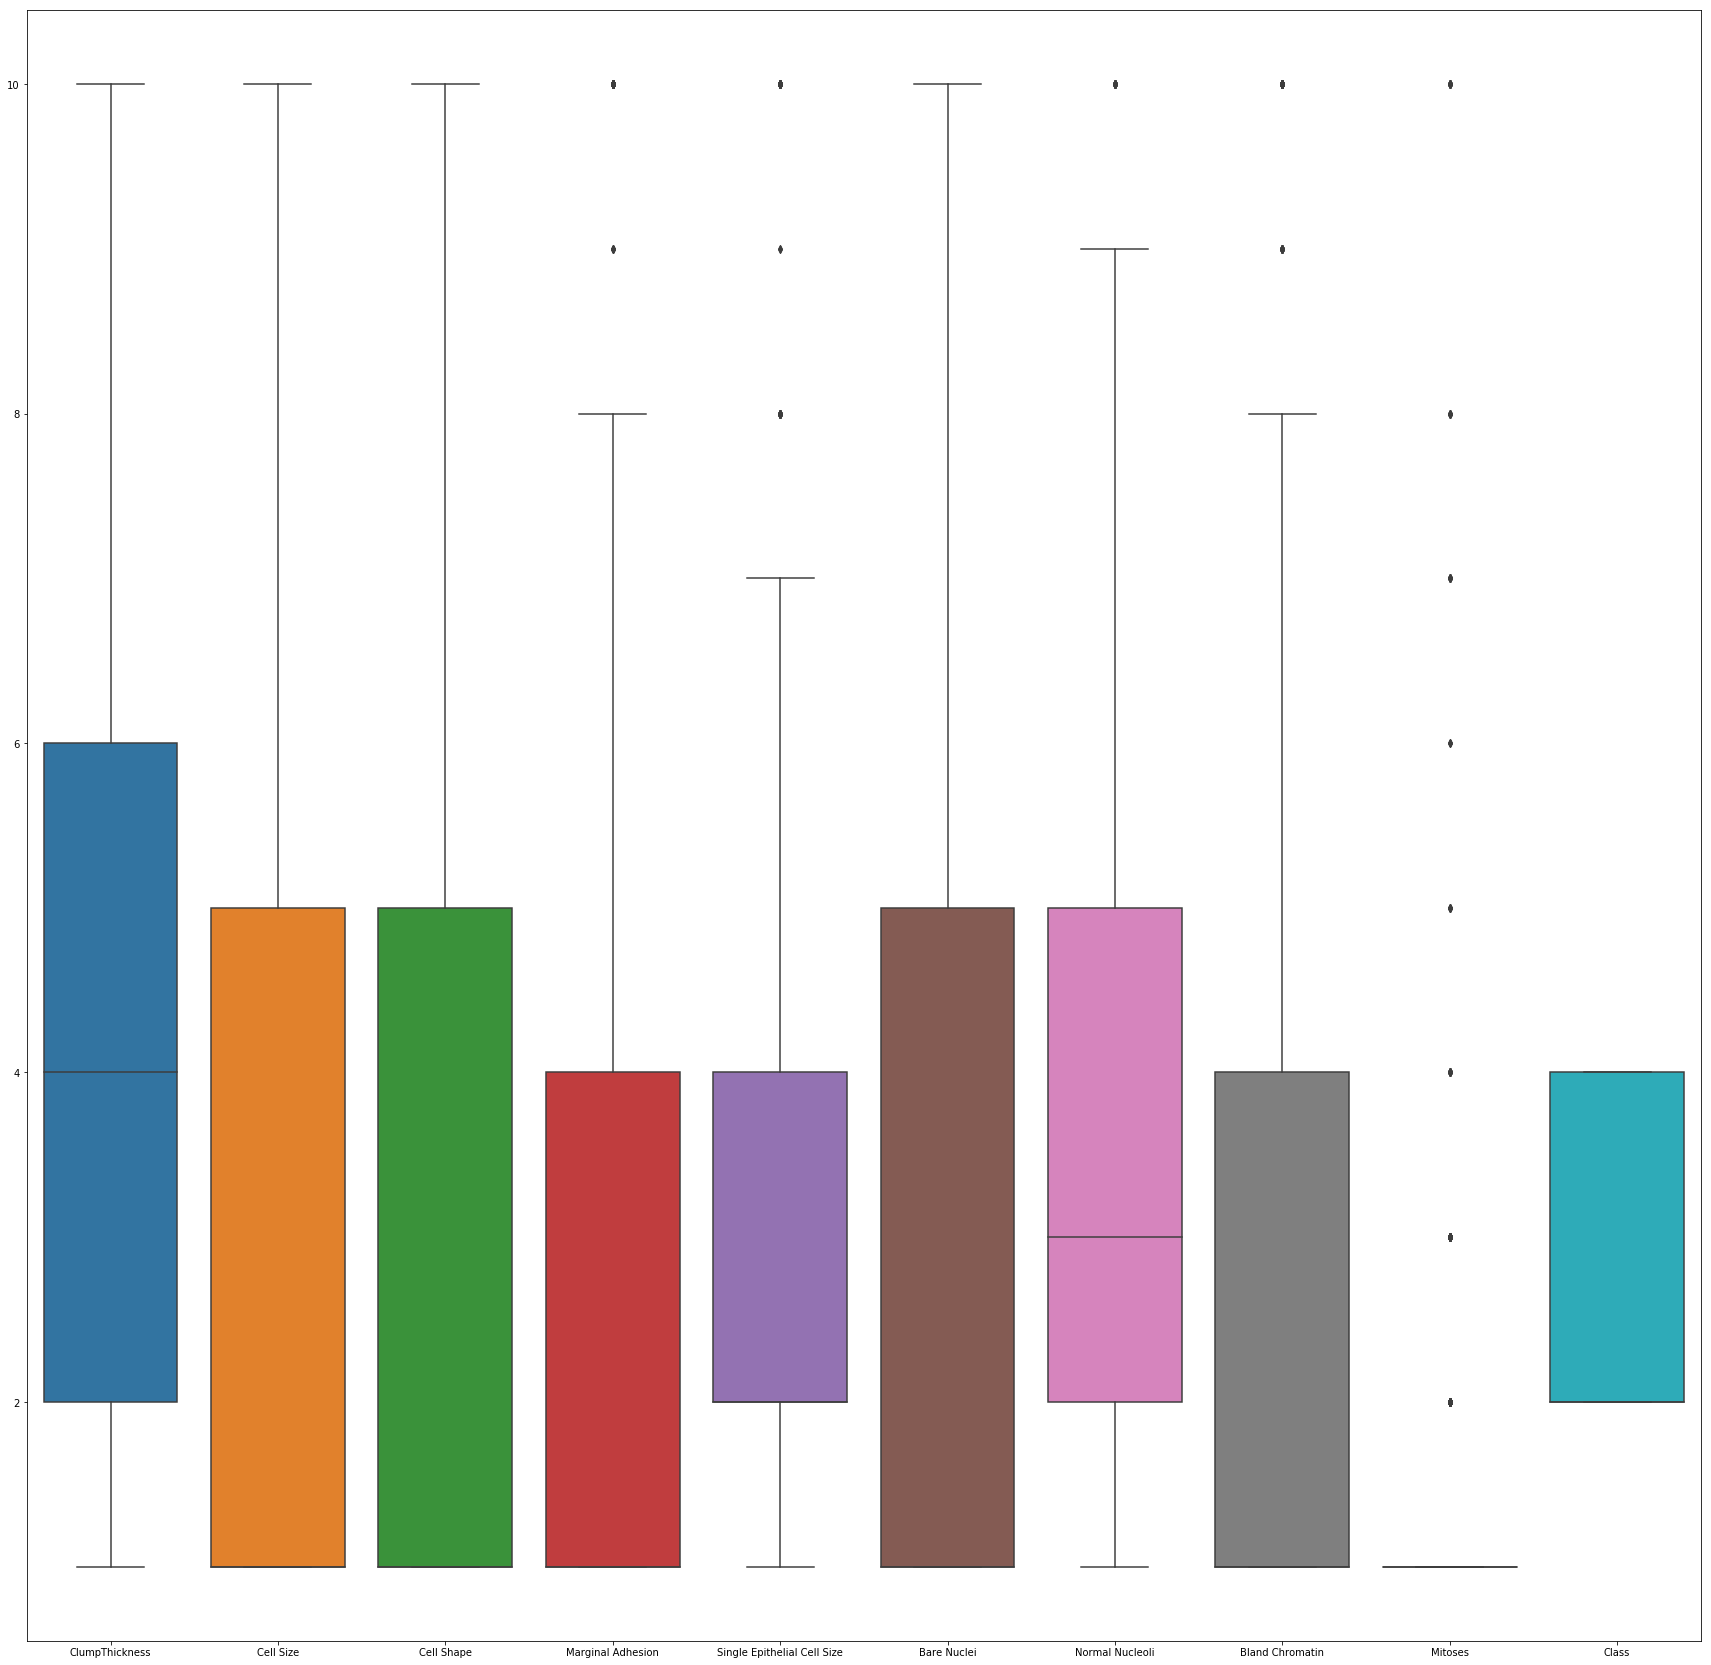

In [133]:
import matplotlib.pyplot as plt
fig, axs=plt.subplots(figsize=(30,30))
plot=sns.boxplot(data=cancer,ax=axs)
#plot.set_xticklabels(plot.get_xticklables(),rotation=40);


In [134]:
#Marginal Adhesion, Single Epithetial Cell Size, Bland Cromatin, Normal Nucleoli, and Mitoses has lot of outliers. That is clear from the box plot above

In [135]:
#To discard the outliers, we can compute the Z-score for each attribute and remove those instances containing attributes with abnormally high or low Z-score (e.g., if Z > 3 or Z <= -3).

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [136]:
Z_cancer = (cancer-cancer.mean())/cancer.std()
Z_cancer

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,0.203519,-0.700433,-0.743663,-0.636616,-0.550622,-0.705300,-0.178353,-0.614023,-0.344340,-0.724311
1,0.203519,0.285978,0.269890,0.758789,1.722257,1.797853,-0.178353,-0.287897,-0.344340,-0.724311
2,-0.506743,-0.700433,-0.743663,-0.636616,-0.550622,-0.427172,-0.178353,-0.614023,-0.344340,-0.724311
3,0.558651,1.601193,1.621293,-0.636616,-0.096046,0.129085,-0.178353,1.342734,-0.344340,-0.724311
4,-0.151612,-0.700433,-0.743663,0.061087,-0.550622,-0.705300,-0.178353,-0.614023,-0.344340,-0.724311
5,1.268913,2.258801,2.296994,1.805343,1.722257,1.797853,2.278302,1.342734,-0.344340,1.378625
6,-1.217005,-0.700433,-0.743663,-0.636616,-0.550622,1.797853,-0.178353,-0.614023,-0.344340,-0.724311
7,-0.861874,-0.700433,-0.405812,-0.636616,-0.550622,-0.705300,-0.178353,-0.614023,-0.344340,-0.724311
8,-0.861874,-0.700433,-0.743663,-0.636616,-0.550622,-0.705300,-0.997239,-0.614023,1.977018,-0.724311
9,-0.151612,-0.371629,-0.743663,-0.636616,-0.550622,-0.705300,-0.587796,-0.614023,-0.344340,-0.724311


In [137]:
print('Number of rows before discarding outliers = %d' % (Z_cancer.shape[0]))
Z2_cancer = Z_cancer.loc[((Z_cancer > -3).sum(axis=1)==10) & ((Z_cancer <= 3).sum(axis=1)==10),:]
print('Number of rows after discarding missing values = %d' % (Z2_cancer.shape[0]))

Number of rows before discarding outliers = 691
Number of rows after discarding missing values = 641


In [138]:
Z2_cancer.shape

(641, 10)

In [139]:
# We could see most of the outliers are now removed.

In [140]:

numerical_cancer = Z2_cancer[['ClumpThickness','Cell Size','Cell Shape','Marginal Adhesion','Single Epithelial Cell Size','Bare Nuclei',
                                           'Normal Nucleoli','Bland Chromatin','Mitoses']]

In [141]:
Z2_cancer

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,0.203519,-0.700433,-0.743663,-0.636616,-0.550622,-0.705300,-0.178353,-0.614023,-0.344340,-0.724311
1,0.203519,0.285978,0.269890,0.758789,1.722257,1.797853,-0.178353,-0.287897,-0.344340,-0.724311
2,-0.506743,-0.700433,-0.743663,-0.636616,-0.550622,-0.427172,-0.178353,-0.614023,-0.344340,-0.724311
3,0.558651,1.601193,1.621293,-0.636616,-0.096046,0.129085,-0.178353,1.342734,-0.344340,-0.724311
4,-0.151612,-0.700433,-0.743663,0.061087,-0.550622,-0.705300,-0.178353,-0.614023,-0.344340,-0.724311
5,1.268913,2.258801,2.296994,1.805343,1.722257,1.797853,2.278302,1.342734,-0.344340,1.378625
6,-1.217005,-0.700433,-0.743663,-0.636616,-0.550622,1.797853,-0.178353,-0.614023,-0.344340,-0.724311
7,-0.861874,-0.700433,-0.405812,-0.636616,-0.550622,-0.705300,-0.178353,-0.614023,-0.344340,-0.724311
8,-0.861874,-0.700433,-0.743663,-0.636616,-0.550622,-0.705300,-0.997239,-0.614023,1.977018,-0.724311
9,-0.151612,-0.371629,-0.743663,-0.636616,-0.550622,-0.705300,-0.587796,-0.614023,-0.344340,-0.724311


In [142]:
output_class = Z2_cancer['Class']

In [143]:
output_class  

0     -0.724311
1     -0.724311
2     -0.724311
3     -0.724311
4     -0.724311
5      1.378625
6     -0.724311
7     -0.724311
8     -0.724311
9     -0.724311
10    -0.724311
11    -0.724311
12     1.378625
13    -0.724311
14     1.378625
15     1.378625
16    -0.724311
17    -0.724311
18     1.378625
19    -0.724311
20     1.378625
21     1.378625
22    -0.724311
23     1.378625
24    -0.724311
25     1.378625
26    -0.724311
27    -0.724311
28    -0.724311
29    -0.724311
         ...   
666   -0.724311
667   -0.724311
668    1.378625
669    1.378625
670    1.378625
671   -0.724311
672   -0.724311
673   -0.724311
674   -0.724311
675   -0.724311
676   -0.724311
677   -0.724311
678   -0.724311
679   -0.724311
681    1.378625
682   -0.724311
683   -0.724311
685   -0.724311
686   -0.724311
687   -0.724311
688   -0.724311
690   -0.724311
691    1.378625
692   -0.724311
693   -0.724311
694   -0.724311
695   -0.724311
696    1.378625
697    1.378625
698    1.378625
Name: Class, Length: 641

# Q6 Create a covariance matrix for identifying Principal components

In [144]:
# PCA
# Step 1 - Create covariance matrix

In [145]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
numerical_cancer_std =  sc.fit_transform(numerical_cancer)          
cov_matrix = np.cov(numerical_cancer_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.0015625  0.61855398 0.62526791 0.47905762 0.49130427 0.57637215
  0.54976009 0.51757242 0.36331128]
 [0.61855398 1.0015625  0.89980047 0.69654362 0.72906337 0.67600603
  0.74706272 0.73380814 0.42553375]
 [0.62526791 0.89980047 1.0015625  0.6751973  0.70244823 0.68984723
  0.72952333 0.72695856 0.38355256]
 [0.47905762 0.69654362 0.6751973  1.0015625  0.60271637 0.6888059
  0.65481644 0.59279073 0.3889835 ]
 [0.49130427 0.72906337 0.70244823 0.60271637 1.0015625  0.58975893
  0.62618788 0.67264899 0.40001368]
 [0.57637215 0.67600603 0.68984723 0.6888059  0.58975893 1.0015625
  0.65829902 0.56862446 0.40770166]
 [0.54976009 0.74706272 0.72952333 0.65481644 0.62618788 0.65829902
  1.0015625  0.67165954 0.32587374]
 [0.51757242 0.73380814 0.72695856 0.59279073 0.67264899 0.56862446
  0.67165954 1.0015625  0.39728848]
 [0.36331128 0.42553375 0.38355256 0.3889835  0.40001368 0.40770166
  0.32587374 0.39728848 1.0015625 ]]


In [146]:
from sklearn.decomposition import PCA

# Q7 Identify eigen values and eigen vector

In [147]:
# Step 2- Get eigen values and eigen vector

In [148]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-2.98303039e-01  4.87744136e-02  8.45090057e-01 -2.73151794e-01
  -5.68611680e-03  1.11847455e-01  2.02481061e-01  2.53874496e-01
  -4.30606774e-02]
 [-3.80217974e-01 -1.05256767e-01 -6.08523624e-02 -1.47386729e-01
  -7.29692745e-01 -2.76622560e-02 -1.06170949e-01 -3.65657773e-01
  -3.75146461e-01]
 [-3.75476109e-01 -1.54601211e-01 -1.24131720e-03 -1.43778662e-01
   6.72924786e-01 -2.70339478e-02 -2.68265339e-01 -3.84767625e-01
  -3.75328247e-01]
 [-3.34478946e-01 -4.48905245e-02 -1.50347794e-01  6.04397908e-01
   4.43562746e-02  2.98716084e-02  2.94531660e-01  4.40780290e-01
  -4.62937825e-01]
 [-3.36782979e-01 -3.52489451e-02 -3.54064799e-01 -2.56442072e-01
   4.77935766e-02  7.35427781e-01  2.79458264e-01  1.36814219e-02
   2.69792455e-01]
 [-3.38010656e-01  6.71369079e-03  2.09630136e-01  5.40135425e-01
  -7.28272882e-02  1.78930322e-01 -5.42827169e-01 -8.47526096e-02
   4.59182357e-01]
 [-3.47487860e-01 -2.24666618e-01 -3.37929107e-02  8.72755319e-02
   5.19827

# Q8 Find variance and cumulative variance by each eigen vector

In [149]:
tot = sum(eigenvalues)
# an array of variance explained by each 
# eigen vector... there will be 9 entries as there are 9 eigen vectors)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)] 

cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 9 entries with 8 th entry 
# cumulative reaching almost 100%
print("Cumulative Variance: \n", cum_var_exp)

Cumulative Variance: 
 [0.64602084 0.73189919 0.79520881 0.85226784 0.89130384 0.92508978
 0.95794313 0.98917493 1.        ]


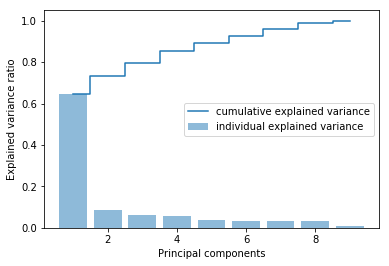

In [150]:
plt.bar(range(1,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

In [151]:
# PCA number of components considered to be 7 in order to maximise the variance to be considered 

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [152]:
from sklearn.decomposition import PCA

In [153]:
PCA = PCA(n_components=7)
PCA.fit(numerical_cancer_std)

PCA(copy=True, iterated_power='auto', n_components=7, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [154]:
numerical_cancer_PCA = PCA.transform(numerical_cancer_std)
numerical_cancer_PCA.shape

(641, 7)

In [155]:
PCA.components_
#Print_ PCA components 
PCA.components_.shape
PCA.explained_variance_

array([5.82327226, 0.77411274, 0.57067693, 0.51433366, 0.35187295,
       0.30454852, 0.29614223])

In [156]:
numerical_cancer_PCA.shape

(641, 7)

In [157]:
PCA.explained_variance_ratio_

array([0.64602084, 0.08587834, 0.06330963, 0.05705903, 0.039036  ,
       0.03378593, 0.03285336])

# Q10 Find correlation between components and features

In [158]:
cancer_pca = pd.DataFrame(numerical_cancer_PCA)
output_class = pd.DataFrame(output_class)

In [159]:
output_class.dtypes

Class    float64
dtype: object

In [160]:
# Pairplot analysis 
cancer_pca_new = pd.concat([cancer_pca,output_class],axis=1)
#cancer_pca.head(10)
#sns.pairplot(cancer_pca, diag_kind='kde',hue="Class")

In [161]:
cancer_pca_new.head()

,0,1,2,3,4,5,6,Class
0,-1.308506,-0.023410,-0.622134,0.247195,-0.145072,0.196433,-0.089339,-0.724311
1,2.076072,-0.494477,0.320569,-0.833551,2.459167,0.751997,0.034347,-0.724311
2,-1.432080,-0.057702,-0.055056,-0.112457,-0.176263,0.361644,0.123876,-0.724311
3,1.958478,-0.836867,-0.154477,1.600850,-0.378716,-0.865145,0.548730,-0.724311
4,-1.164642,-0.075711,-0.193707,-0.314487,-0.163878,-0.140065,-0.330649,-0.724311


C:\Users\sugan\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:448: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.
C:\Users\sugan\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:448: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.
C:\Users\sugan\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\Users\sugan\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X,

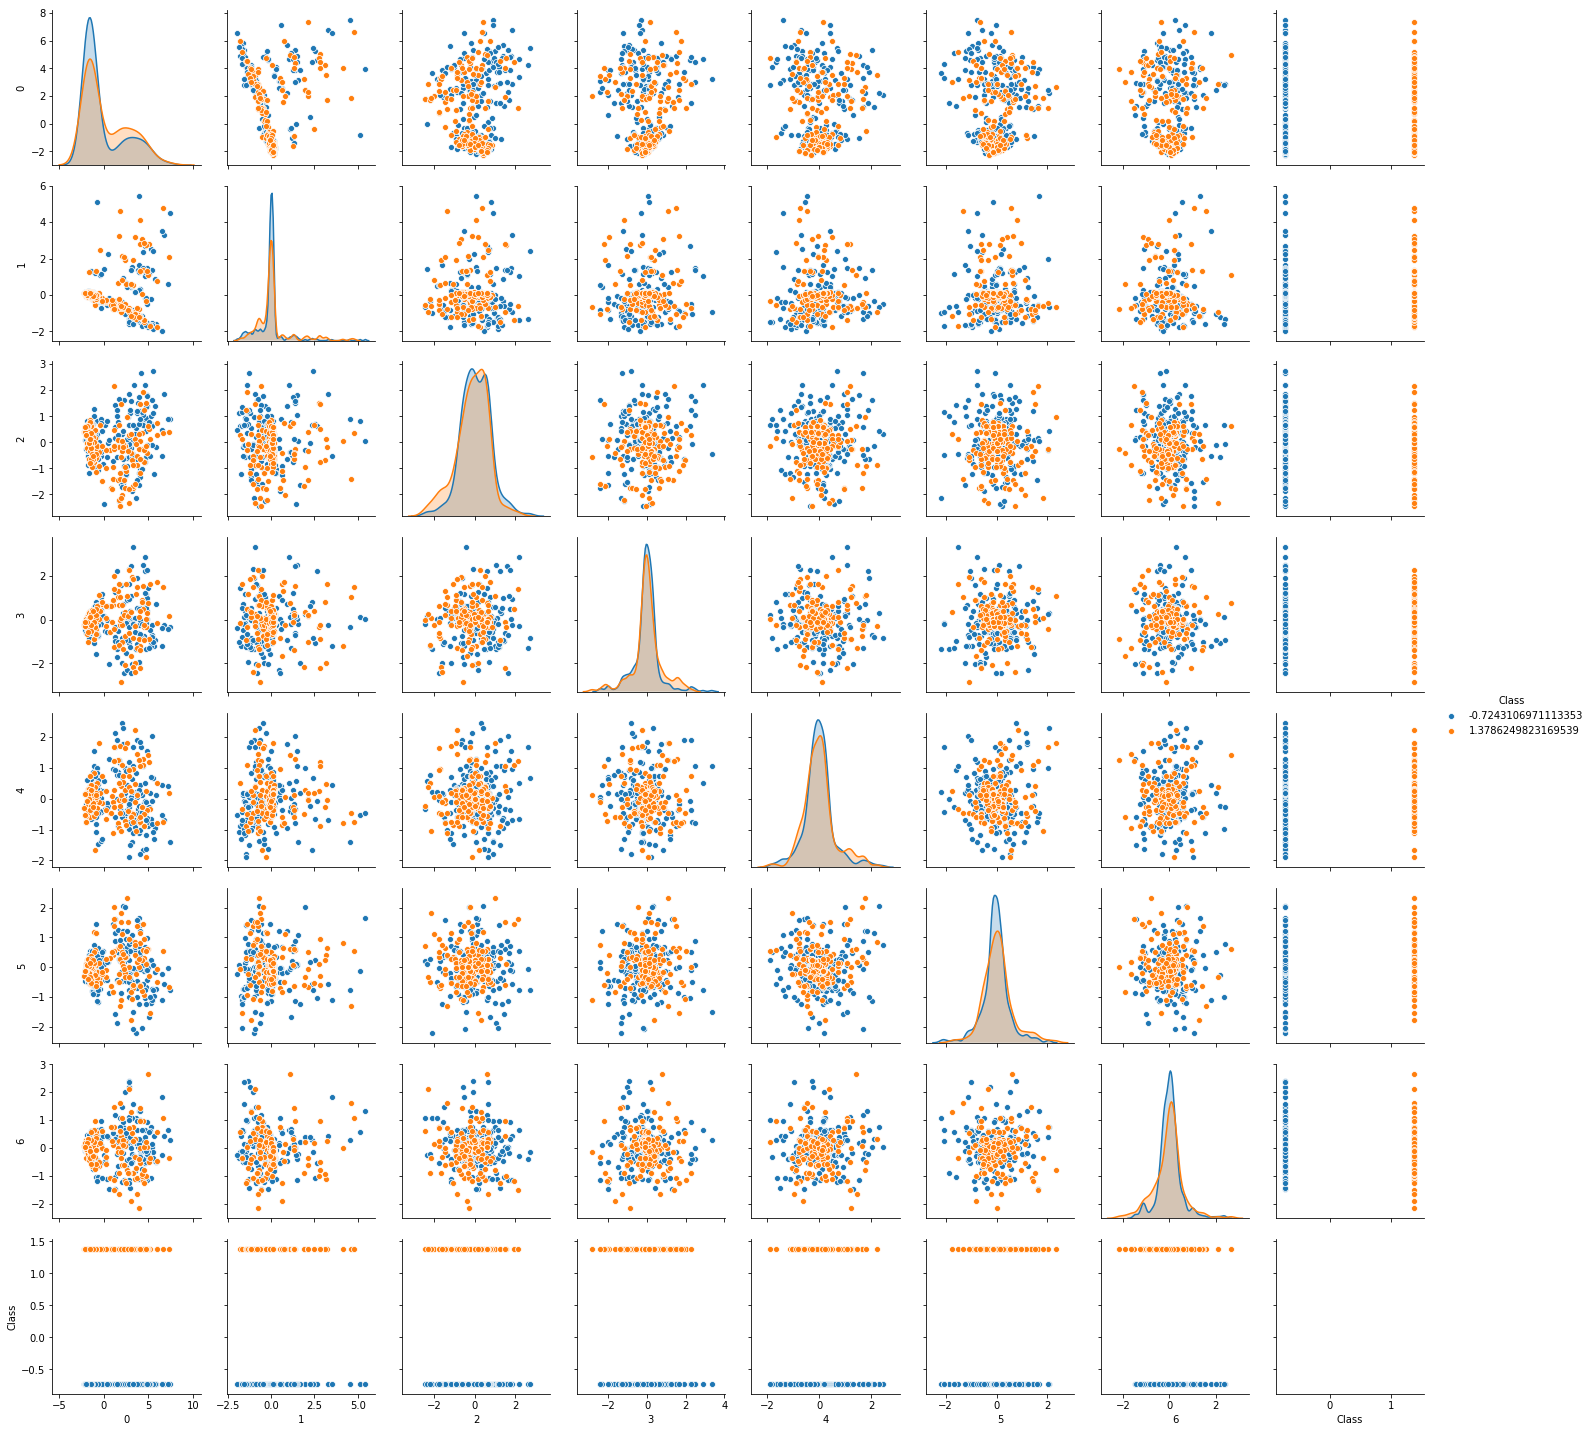

In [162]:
sns.pairplot(data=cancer_pca_new,hue='Class')

In [163]:
# More normal distribution can be now visually seen. The correlation between variables has come down clearly. Peaks are more visible

Text(0.5, 1.0, 'Correlations')

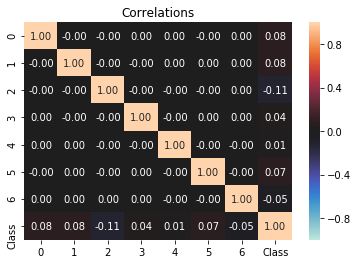

In [164]:
corr_matrix = cancer_pca_new.corr()
sns.heatmap(corr_matrix,vmin=-1,vmax=1,center=0,annot=True,fmt='.2f')
plt.title('Correlations')

In [165]:
# Post PCA from the above graph, it can be seen that successfully the correlation has come down.